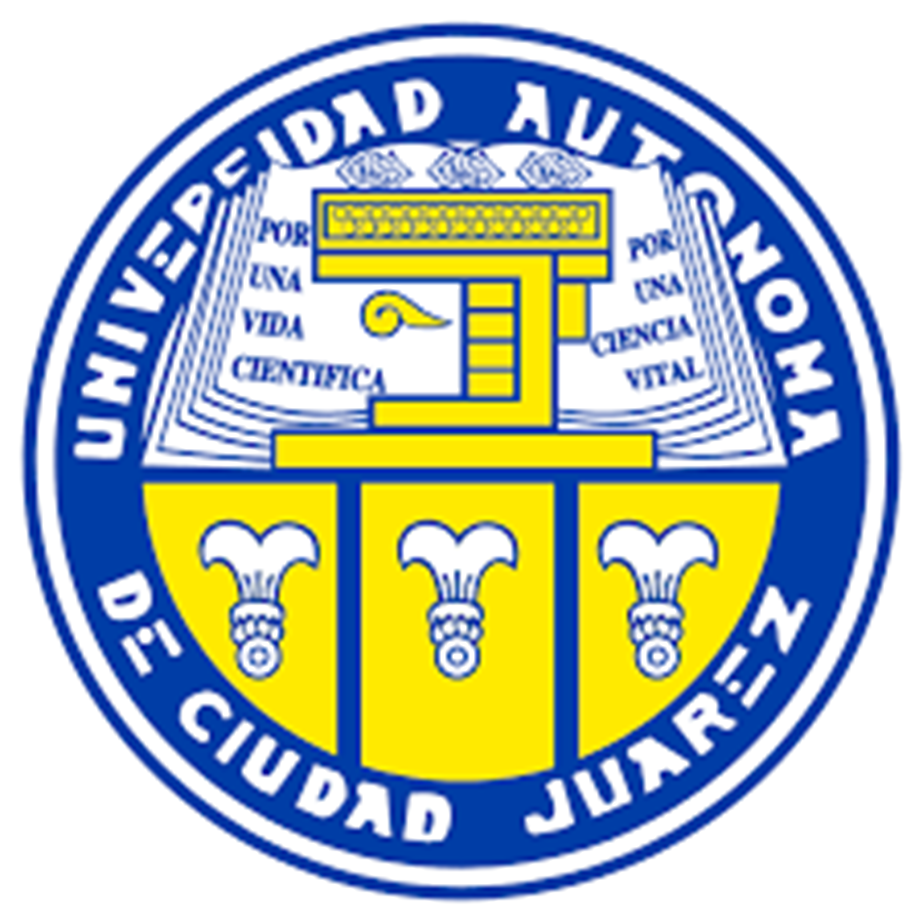


# Nombre: Sergio Trejo
# Matricula: 261539
# Materia: Redes neuronales profundas_A_Presencial_260206

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.applications import DenseNet121, ResNet50, MobileNetV2
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet
from tensorflow.keras.applications.resnet import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import os
print(os.getcwd())

In [ ]:
# Carpeta que contiene:
# lung_aca  -> Adenocarcinoma
# lung_n    -> Tejido sano
# lung_scc  -> Carcinoma escamoso

directory = "/home/sergioai/ml_projects/maestria/2do_semestre/redes_neuronales/semana_04/lung_image_sets"

#generador con el 15% de validacion 

generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.15,
    fill_mode='nearest'
)

training_generator = generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    subset='training',
    seed=30
)

val_generator = generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    subset='validation',
    seed=30
)

In [ ]:
print(training_generator.class_indices)

In [ ]:
x,y=next(training_generator)

from random import seed, randint

plt.figure(1, figsize=(20,6))
plt.tight_layout()
for i in range(8):
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+1)

    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+9)

    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
plt.show()

## Modelo 1 - DenseNet121

In [ ]:
#Cargar el modelo preentrenado
base_model_1 = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

#Congelar convoluciones
base_model_1.trainable = False

#Nueva cabeza clasificadora
inputs = keras.Input(shape=(224,224,3))
x = preprocess_densenet(inputs)
x = base_model_1(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model_densenet = Model(inputs, outputs)

model_densenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_densenet = model_densenet.fit(
    training_generator,
    epochs=8,
    validation_data=val_generator
)

# Matriz de Confusion DenseNet
val_generator.reset()
preds = model_densenet.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusion - DenseNet121")
plt.show()

## MODELO 2 – ResNet50

In [ ]:
#Cargar el modelo preentrenado
base_model_2 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
#Congelar convoluciones
base_model_2.trainable = False

#Nueva cabeza clasificadora
inputs = keras.Input(shape=(224,224,3))
x = preprocess_resnet(inputs)
x = base_model_2(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model_resnet = Model(inputs, outputs)

model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    training_generator,
    epochs=8,
    validation_data=val_generator
)

# Matriz de Confusion ResNet
val_generator.reset()
preds = model_resnet.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusion - ResNet50")
plt.show()

## MODELO 3 – MobileNetV2

In [ ]:
#Cargar el modelo preentrenado
base_model_3 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

#Congelar convoluciones
base_model_3.trainable = False

#Nueva cabeza clasificadora
inputs = keras.Input(shape=(224,224,3))
x = preprocess_mobilenet(inputs)
x = base_model_3(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model_mobilenet = Model(inputs, outputs)

model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    training_generator,
    epochs=8,
    validation_data=val_generator
)

# Matriz de Confusion MobileNet
val_generator.reset()
preds = model_mobilenet.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusion - MobileNetV2")
plt.show()